In [ ]:
import pandas as pd
import numpy as np

# run this command in terminal first: pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# run this command in terminal first: pip install pandas scikit-learn xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel

# run this command in terminal first: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('cleaned_yrbs_data.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15694 entries, 0 to 15693
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15694 non-null  float64
 1   gender                      15694 non-null  str    
 2   education_level             15694 non-null  str    
 3   ride_drinking_driver        15694 non-null  float64
 4   school_safety_concern       15694 non-null  float64
 5   threatened_at_school        15694 non-null  float64
 6   fight_count                 15694 non-null  float64
 7   school_fight_count          15694 non-null  float64
 8   neighborhood_violence       15694 non-null  float64
 9   sexual_violence             15694 non-null  float64
 10  school_racism               15694 non-null  float64
 11  school_bullying             15694 non-null  float64
 12  cyber_bullying              15694 non-null  float64
 13  feel_hopeless               15694 non-null

C:\Users\Norawit\AppData\Local\Temp\ipykernel_28380\3488811937.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


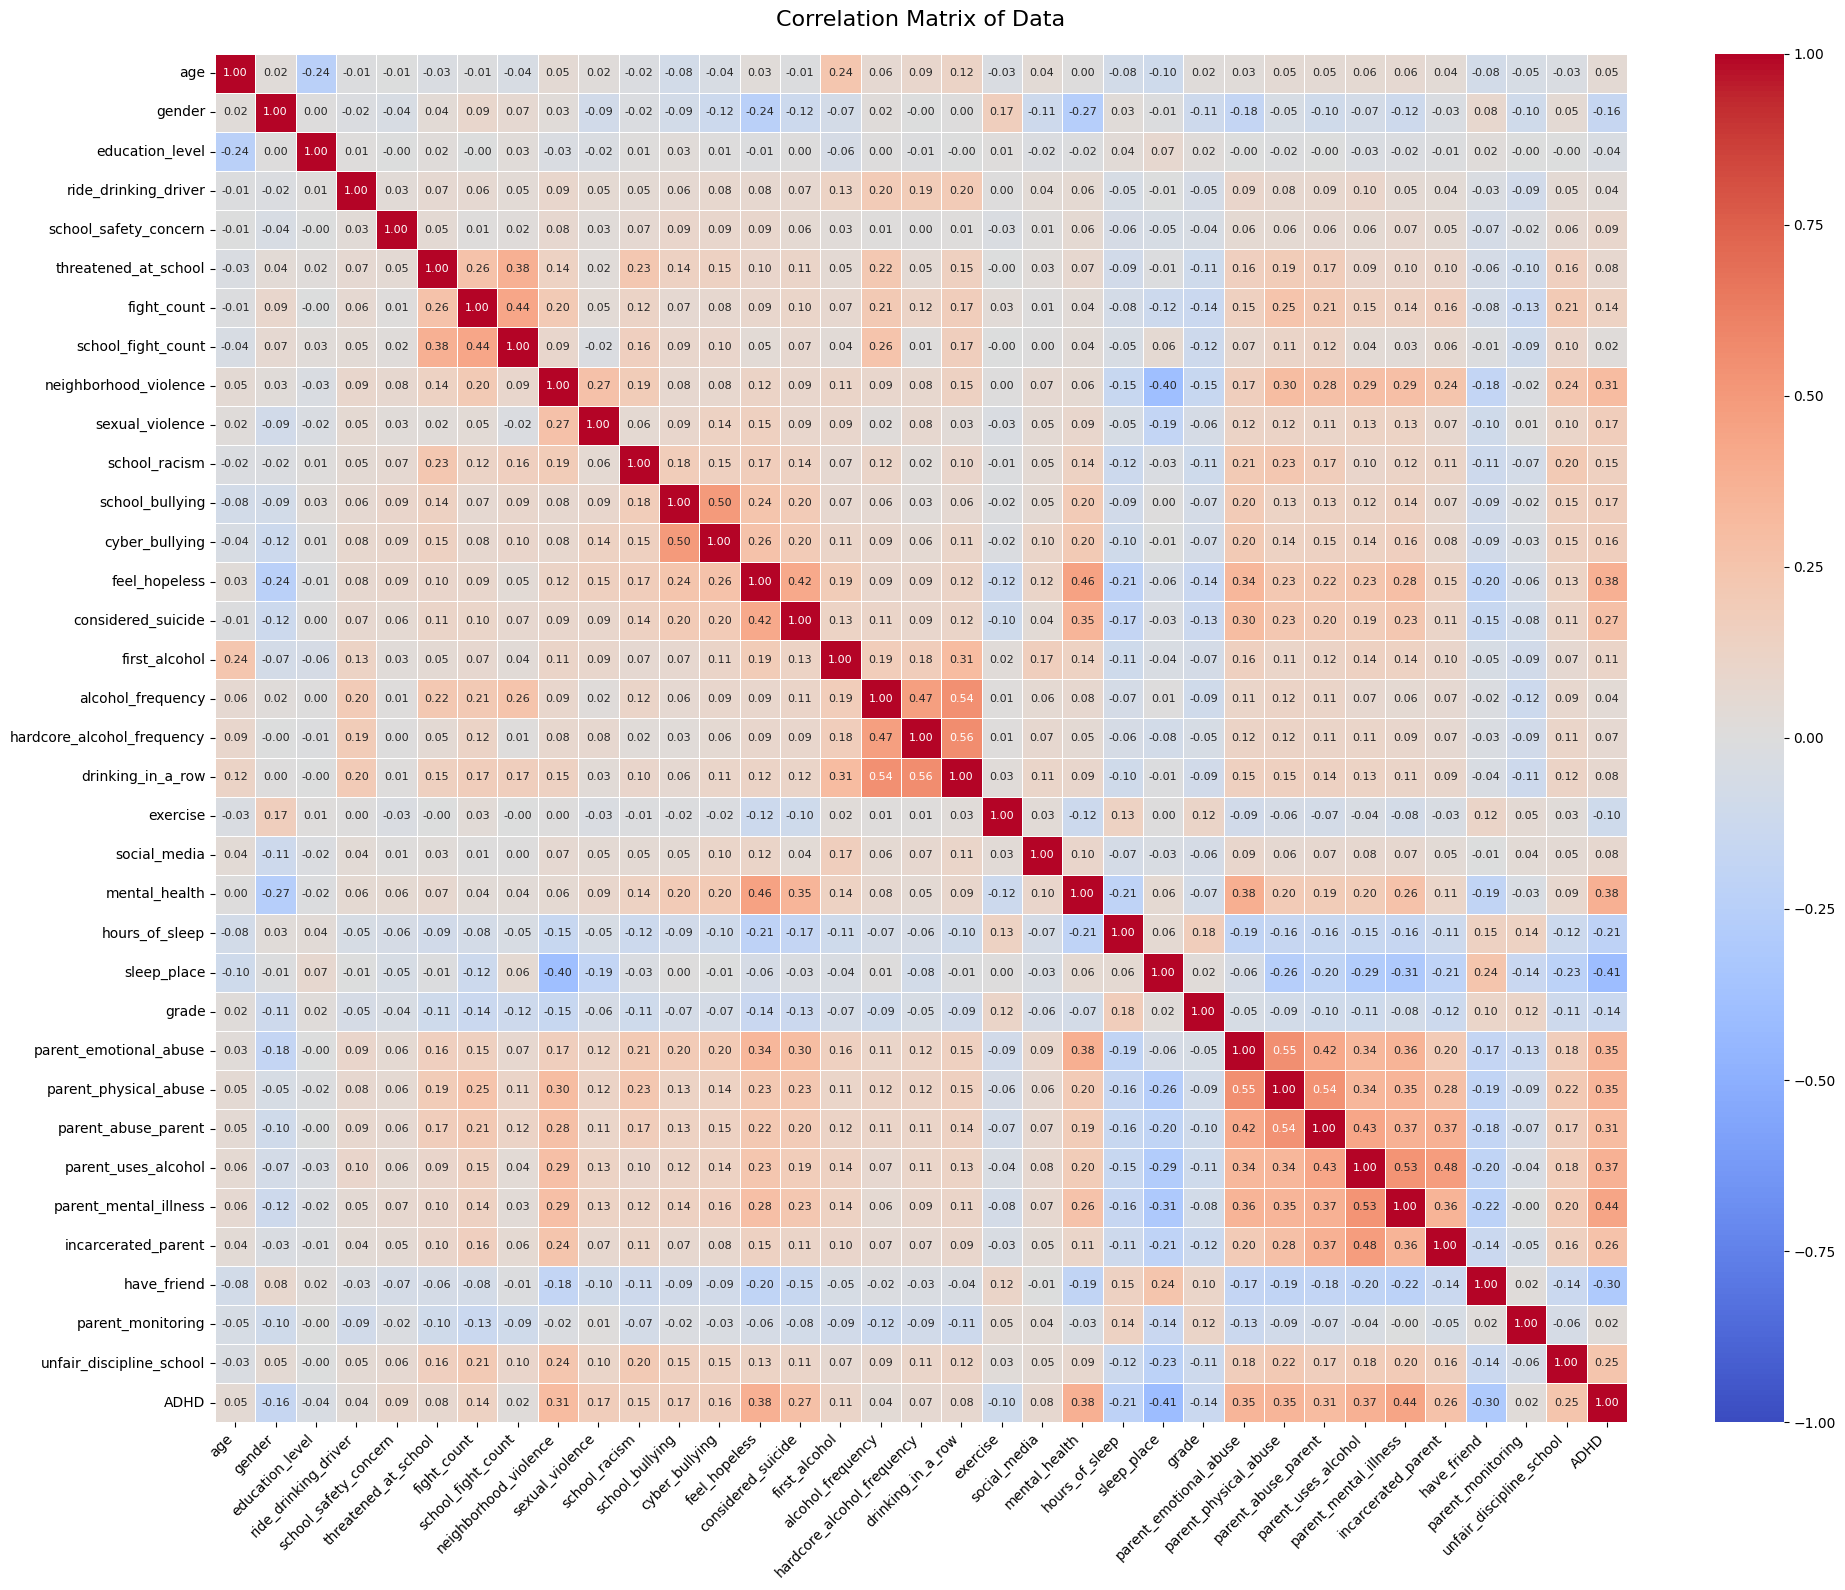

In [4]:
from sklearn.preprocessing import LabelEncoder


df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(20, 16))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f",
            annot_kws={"size": 8},
            linewidths=0.5,
            vmin=-1, vmax=1
            )   

plt.title('Correlation Matrix of Data', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
le = LabelEncoder()
df['grade_encoded'] = le.fit_transform(df['grade'])

X = df.drop(columns=['grade', 'grade_encoded'])
y = df['grade_encoded']

#  Column ที่เป็น String 
cat_features = ['gender', 'education_level', 'considered_suicide', 'sleep_place']

# แปลงประเภทข้อมูลให้เป็น category
for col in cat_features:
    X[col] = X[col].astype('category')

# แบ่งข้อมูลเป็น Train/Test -> 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# เทรนโมเดล
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    enable_categorical=True,  # เอาไว้ให้ใช้ category ที่แปลงมา
    tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)

# ทดสอบโมเดล
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

Accuracy: 0.4438
              precision    recall  f1-score   support

         0.0       0.32      0.12      0.18        90
         1.0       0.09      0.02      0.03       154
         2.0       0.35      0.15      0.21       565
         3.0       0.38      0.32      0.35      1052
         4.0       0.49      0.75      0.60      1278

    accuracy                           0.44      3139
   macro avg       0.33      0.27      0.27      3139
weighted avg       0.40      0.44      0.40      3139



C:\Users\Norawit\AppData\Local\Temp\ipykernel_28380\4047624257.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


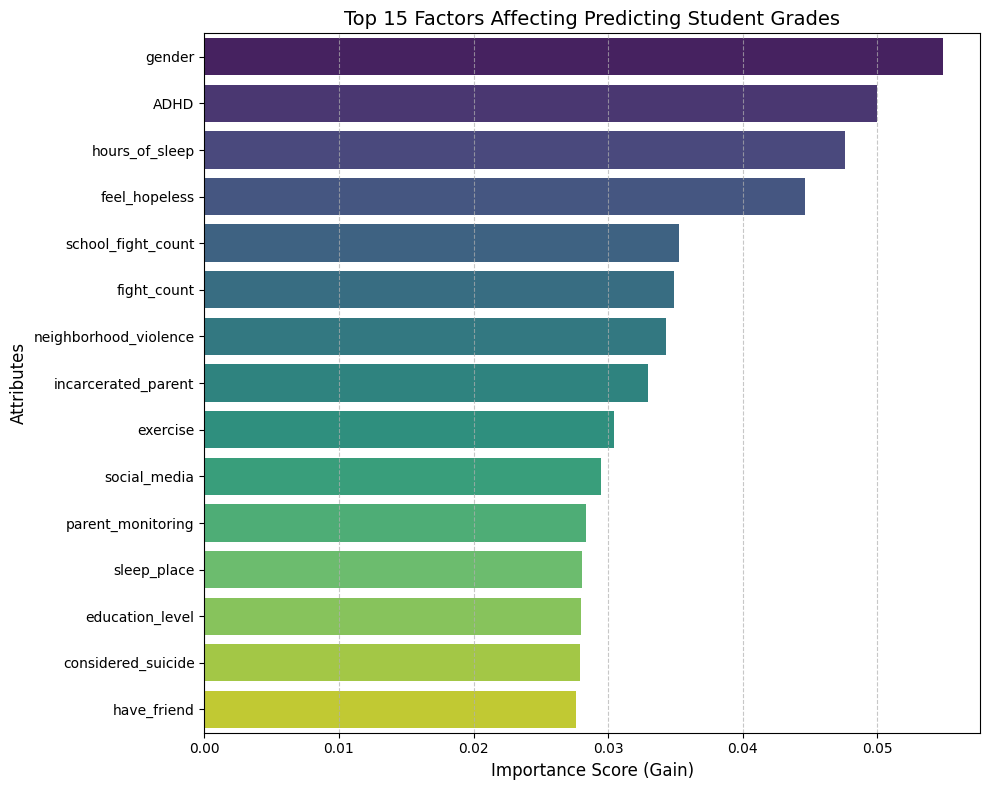

In [6]:
# ดึงค่าความสำคัญของ Feature ออกมา
importances = model.feature_importances_
feature_names = X.columns

# สร้าง DataFrame แล้วเอาไป plot
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# วาดกราฟ 
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15),
    palette='viridis'
)

plt.title('Top 15 Factors Affecting Predicting Student Grades', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Attributes', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
# ยุบกลุ่มเกรดเป็น 3 กลุ่ม (Low, Mid, High) เพื่อดูภาพรวม

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# ยุบเกรดเป็น 3 กลุ่ม (Low, Mid, High) เพื่อดูภาพรวม
# สร้าง Dictionary ใช้ Mapping
# 0,1 -> 0 (Low) | 2 -> 1 (Mid) | 3,4 -> 2 (High)
grade_group_map = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}
y_grouped = df['grade'].astype(int).map(grade_group_map)

# Feature Engineering
# Sleep x ADHD: ดูว่าการพักผ่อนน้อยส่งผลกับเด็ก ADHD แค่ไหน
df['sleep_adhd_interaction'] = df['hours_of_sleep'] * df['ADHD']

# สร้าง X จาก Features ที่มีประสิทธิภาพสูงสุดคราวที่แล้ว
X = df.drop(columns=['grade', 'gender', 'education_level', 'sleep_place', 'grade_encoded'], errors='ignore')

# จัดการ String ใน X ให้เป็นตัวเลขทั้งหมด
for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_grouped, test_size=0.2, random_state=42, stratify=y_grouped
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#  Hyperparameters Tuning
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,           # ลดความลึกเพื่อป้องกันการจำ Noise
    min_child_weight=5,    # บังคับให้แต่ละโหนดต้องมีข้อมูลจำนวนหนึ่ง
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    objective='multi:softprob'
)

model.fit(X_train_res, y_train_res)

# --- 5. วัดผลลัพธ์ ---
y_pred = model.predict(X_test)
print(f"--- ผลลัพธ์หลังยุบกลุ่มเกรด (3 กลุ่ม) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

# ดูความเสถียรด้วย Cross Validation
cv_scores = cross_val_score(model, X, y_grouped, cv=5)
print(f"CV Accuracy เฉลี่ย: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# กำหนดชื่อกลุ่มใหม่สำหรับการรายงานผล
target_names = ['Low (GPA 0-1)', 'Mid (GPA 2)', 'High (GPA 3-4)']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

--- ผลลัพธ์หลังยุบกลุ่มเกรด (3 กลุ่ม) ---
Accuracy Score: 0.7251
CV Accuracy เฉลี่ย: 0.7444 (+/- 0.0012)

Classification Report:
                precision    recall  f1-score   support

 Low (GPA 0-1)       0.25      0.20      0.22       270
   Mid (GPA 2)       0.24      0.02      0.03       533
High (GPA 3-4)       0.77      0.95      0.85      2336

      accuracy                           0.73      3139
     macro avg       0.42      0.39      0.37      3139
  weighted avg       0.63      0.73      0.65      3139



In [8]:
# เตรียมข้อมูล
y = df['grade'].astype(int)

# Feature Engineering 
df['sleep_adhd_interaction'] = df['hours_of_sleep'] * df['ADHD']

X = df.drop(columns=['grade', 'gender', 'education_level', 'sleep_place', 'grade_encoded'], errors='ignore')

# จัดการ Missing values และ Numeric conversion
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

# แบ่งข้อมูลและปรับสมดุล (SMOTE)
# เนื่องจากมี 5 กลุ่ม การทำ SMOTE จะช่วยป้องกันไม่ให้โมเดลมองข้ามกลุ่ม F หรือ D
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

model = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob', # ใช้ softprob เพื่อให้โมเดลคำนวณความน่าจะเป็นของแต่ละเกรด
    num_class=5,                # กำหนดจำนวนคลาสชัดเจน
    random_state=42
)

model.fit(X_train_res, y_train_res)

# Evaluate the model
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

# Report 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['F', 'D', 'C', 'B', 'A']))

# Check Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Features:")
print(importances.head(5))

Accuracy Score: 0.4368

Classification Report:
              precision    recall  f1-score   support

           F       0.18      0.11      0.14       101
           D       0.16      0.04      0.07       168
           C       0.31      0.12      0.17       534
           B       0.36      0.31      0.33      1019
           A       0.50      0.74      0.60      1317

    accuracy                           0.44      3139
   macro avg       0.30      0.26      0.26      3139
weighted avg       0.39      0.44      0.39      3139


Top 5 Features:
feel_hopeless            0.092633
hours_of_sleep           0.047834
neighborhood_violence    0.046757
school_fight_count       0.038939
parent_monitoring        0.038644
dtype: float32


In [9]:
# สร้าง DF รวมชื่อ Feature และค่า Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# แสดงผลในรูปแบบตาราง
print("--- ตารางความสำคัญของทุกฟีเจอร์ ---")
print(feature_importances)

# Save as CSV kub
feature_importances.to_csv('feature_importance_all.csv', index=False)

--- ตารางความสำคัญของทุกฟีเจอร์ ---
                       Feature  Importance
11               feel_hopeless    0.092633
20              hours_of_sleep    0.047834
6        neighborhood_violence    0.046757
5           school_fight_count    0.038939
28           parent_monitoring    0.038644
26         incarcerated_parent    0.037933
9              school_bullying    0.034536
24         parent_uses_alcohol    0.033771
0                          age    0.033530
21      parent_emotional_abuse    0.032983
29    unfair_discipline_school    0.032030
18                social_media    0.032007
17                    exercise    0.031857
2        school_safety_concern    0.031442
4                  fight_count    0.028436
19               mental_health    0.028282
10              cyber_bullying    0.028000
8                school_racism    0.027881
31      sleep_adhd_interaction    0.027385
30                        ADHD    0.026827
25       parent_mental_illness    0.026617
7              sex

C:\Users\Norawit\AppData\Local\Temp\ipykernel_28380\3115833465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


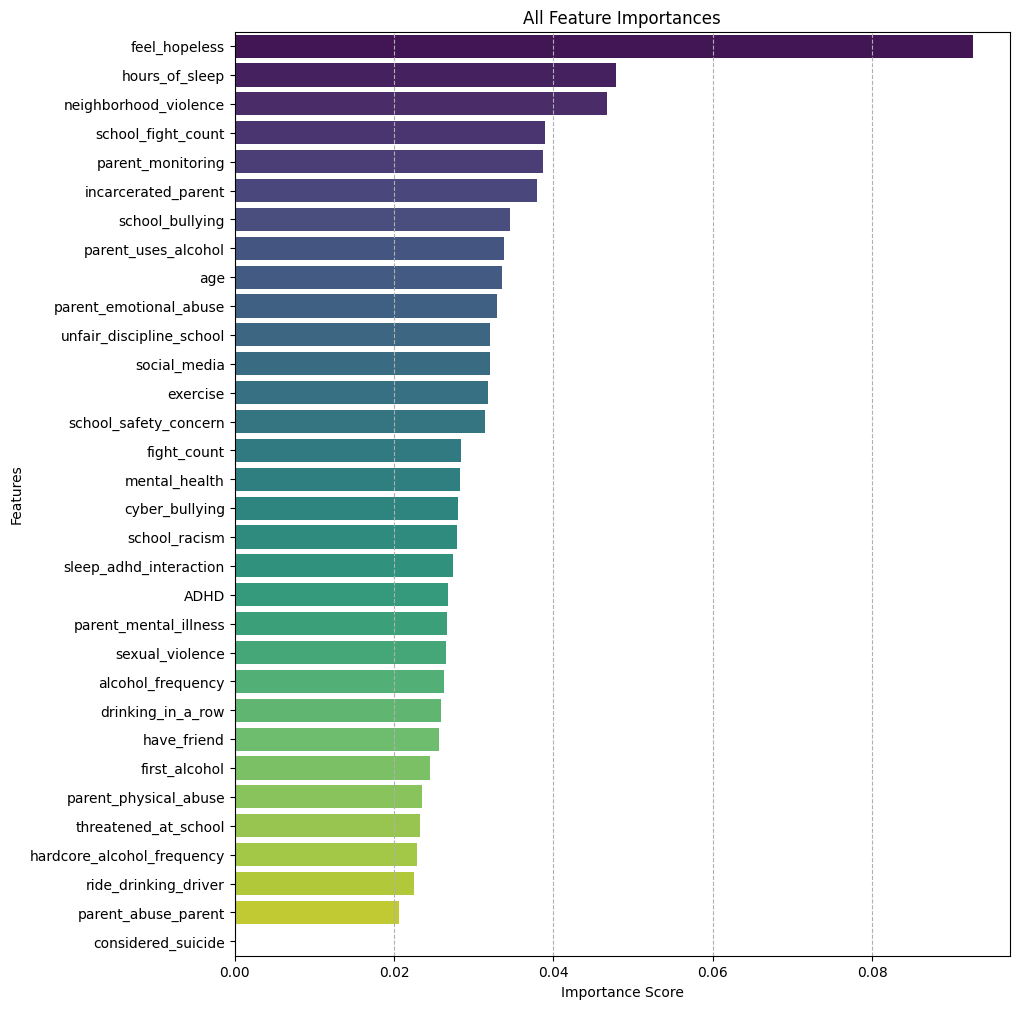

In [10]:
plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('All Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--')
plt.show()


Categorical columns: ['gender', 'education_level', 'considered_suicide', 'sleep_place']
Numerical columns: ['age', 'ride_drinking_driver', 'school_safety_concern', 'threatened_at_school', 'fight_count', 'school_fight_count', 'neighborhood_violence', 'sexual_violence', 'school_racism', 'school_bullying', 'cyber_bullying', 'feel_hopeless', 'first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row', 'exercise', 'social_media', 'mental_health', 'hours_of_sleep', 'parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'have_friend', 'parent_monitoring', 'unfair_discipline_school', 'ADHD']
Total features after engineering: 58

--- Model Evaluation ---
Accuracy Score: 0.4393

Classification Report:
              precision    recall  f1-score   support

           F       0.41      0.07      0.12       101
           D       0.00      0.00      0.00       168
           C     

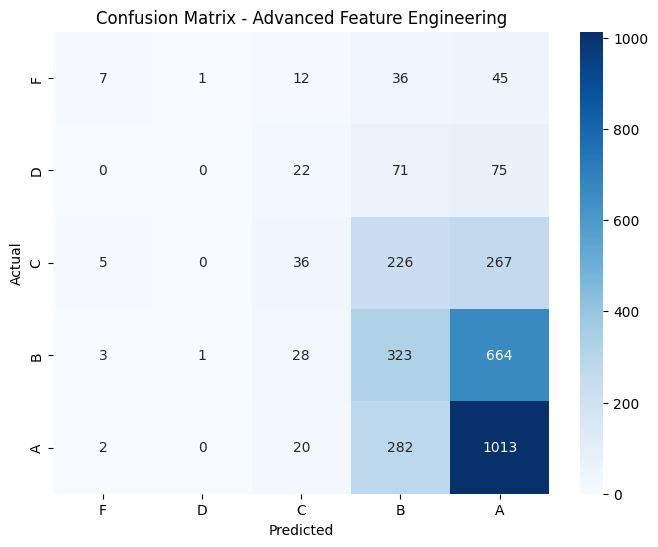

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_yrbs_data.csv')

# Identify categorical and numerical columns
categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['grade']]

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

y = df['grade'].astype(int)

# Health & Lifestyle Group
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df['health_score'] = df[health_cols].sum(axis=1)
df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# Alcohol Use Group
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family Environment Group
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 
               'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)  # Exclude monitoring
df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# School Environment Group
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 
               'school_racism', 'school_bullying', 'unfair_discipline_school']
df['school_stress_score'] = df[school_cols].sum(axis=1)
df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df['cyber_bullying'] > 0)).astype(int)
df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# Social & Peer Group
social_cols = ['social_media', 'have_friend']
df['social_engagement'] = df['social_media'] + df['have_friend']
df['social_risk'] = (df['social_media'] > 5).astype(int)
df['peer_support'] = df['have_friend']

# Violence & Safety Group
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
df['personal_violence'] = df['fight_count'] + df['sexual_violence']
df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# Demographic & Developmental Group
demo_cols = ['age']
df['age_squared'] = df['age'] ** 2
df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)

# Cross-domain Interactions
df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

# Update numerical columns list with all new features
grouped_features = [
    'health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction',
    'alcohol_exposure', 'alcohol_progression', 'high_alcohol_use',
    'family_adversity_score', 'family_protective_score', 'family_risk_ratio',
    'school_stress_score', 'bullying_exposure', 'school_violence_index',
    'social_engagement', 'social_risk', 'peer_support',
    'violence_exposure_score', 'personal_violence', 'environmental_violence',
    'age_squared', 'adolescent_risk',
    'health_substance_risk', 'family_school_stress', 'social_violence_link'
]

numerical_cols.extend(grouped_features)

X = df[numerical_cols + categorical_cols]

# Handle missing values
X = X.fillna(X.median(numeric_only=True))
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print(f"Total features after engineering: {X.shape[1]}")

# Split data (80/20) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Feature selection using XGBoost feature importances
selector_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

# Create pipeline with feature selection
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(selector_model, threshold='median')),
    ('classifier', XGBClassifier(
        n_estimators=533,
        learning_rate=0.0241238,
        max_depth=3,
        min_child_weight=6,
        subsample=0.89438,
        colsample_bytree=0.60395,
        objective='multi:softprob',
        num_class=5,
        random_state=42
    ))
])

# Train model
full_pipeline.fit(X_train, y_train)

# Evaluate model
y_pred = full_pipeline.predict(X_test)
print(f"\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['F', 'D', 'C', 'B', 'A']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['F', 'D', 'C', 'B', 'A'],
            yticklabels=['F', 'D', 'C', 'B', 'A'])
plt.title('Confusion Matrix - Advanced Feature Engineering')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

C:\Users\Norawit\AppData\Local\Temp\ipykernel_28380\3365767405.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


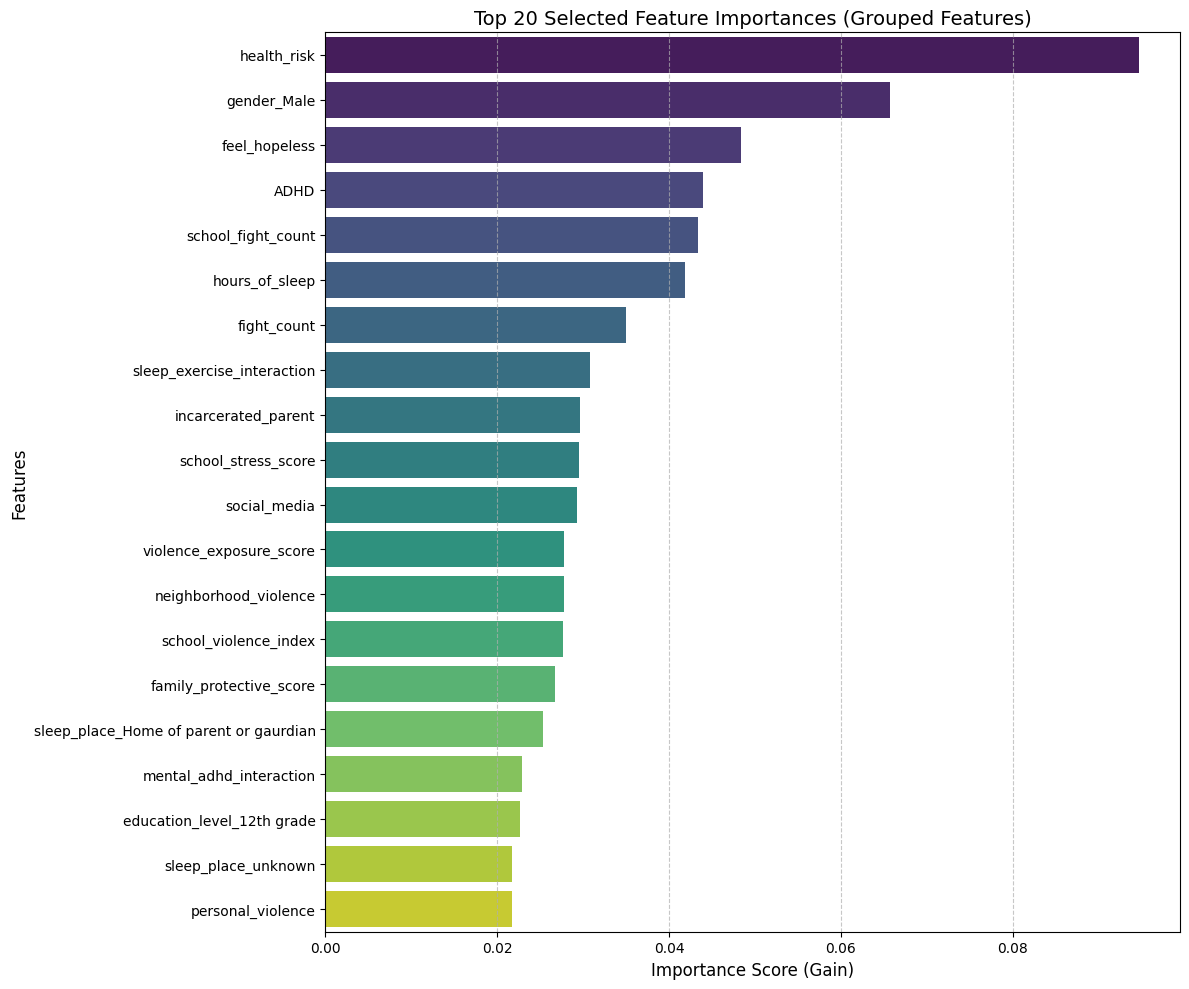


Selected 35 out of 70 features

Top 10 Most Important Features:
                       Feature  Importance
14                 health_risk    0.094750
28                 gender_Male    0.065674
5                feel_hopeless    0.048383
13                        ADHD    0.044012
1           school_fight_count    0.043385
8               hours_of_sleep    0.041838
0                  fight_count    0.035023
15  sleep_exercise_interaction    0.030800
10         incarcerated_parent    0.029695
20         school_stress_score    0.029480

--- Feature Group Analysis ---


C:\Users\Norawit\AppData\Local\Temp\ipykernel_28380\3365767405.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Importance', y='Group', data=group_df, palette='Set2')


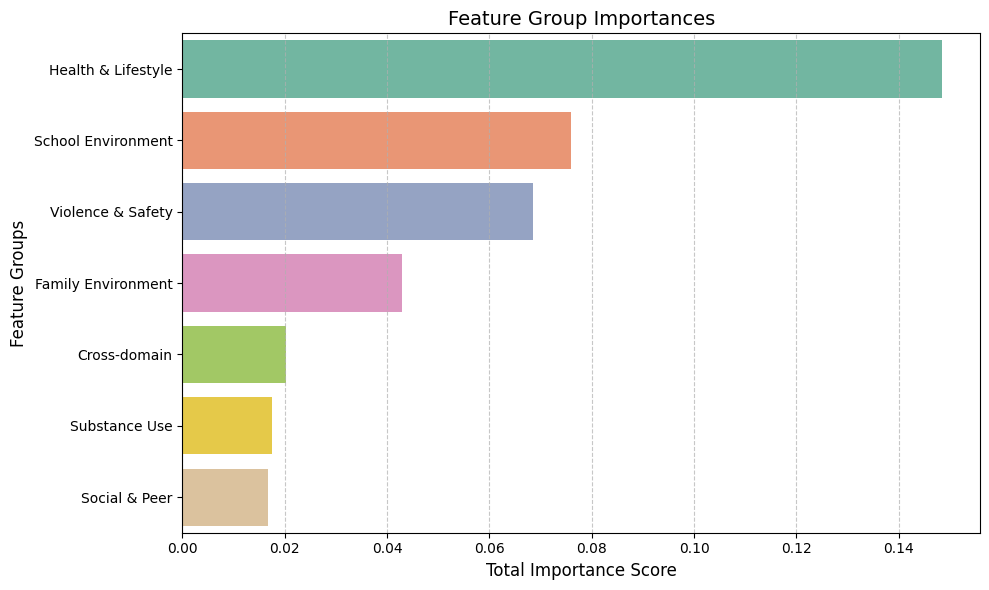


Feature Group Rankings:
                Group  Total_Importance
0  Health & Lifestyle          0.148448
3  School Environment          0.075879
5   Violence & Safety          0.068455
2  Family Environment          0.042916
6        Cross-domain          0.020204
1       Substance Use          0.017434
4       Social & Peer          0.016686


In [14]:
# Feature Importance Analysis
# Get selected feature names
selected_features_mask = full_pipeline.named_steps['selector'].get_support()
all_feature_names = (numerical_cols + 
                    list(full_pipeline.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .get_feature_names_out(categorical_cols)))

selected_feature_names = [name for name, selected in zip(all_feature_names, selected_features_mask) if selected]
selected_importances = full_pipeline.named_steps['classifier'].feature_importances_

# Create DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': selected_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 selected features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Selected Feature Importances (Grouped Features)', fontsize=14)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Save feature importances
feature_importance_df.to_csv('feature_importance_grouped.csv', index=False)

print(f"\nSelected {len(selected_feature_names)} out of {len(all_feature_names)} features")
print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

# Group analysis
print("\n--- Feature Group Analysis ---")
feature_groups = {
    'Health & Lifestyle': ['health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction'],
    'Substance Use': ['alcohol_exposure', 'alcohol_progression', 'high_alcohol_use'],
    'Family Environment': ['family_adversity_score', 'family_protective_score', 'family_risk_ratio'],
    'School Environment': ['school_stress_score', 'bullying_exposure', 'school_violence_index'],
    'Social & Peer': ['social_engagement', 'social_risk', 'peer_support'],
    'Violence & Safety': ['violence_exposure_score', 'personal_violence', 'environmental_violence'],
    'Demographic': ['age_squared', 'adolescent_risk'],
    'Cross-domain': ['health_substance_risk', 'family_school_stress', 'social_violence_link']
}

group_importances = {}
for group, features in feature_groups.items():
    group_features_in_selected = [f for f in features if f in selected_feature_names]
    if group_features_in_selected:
        group_importance = feature_importance_df[feature_importance_df['Feature'].isin(group_features_in_selected)]['Importance'].sum()
        group_importances[group] = group_importance

group_df = pd.DataFrame(list(group_importances.items()), columns=['Group', 'Total_Importance']).sort_values('Total_Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Importance', y='Group', data=group_df, palette='Set2')
plt.title('Feature Group Importances', fontsize=14)
plt.xlabel('Total Importance Score', fontsize=12)
plt.ylabel('Feature Groups', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nFeature Group Rankings:")
print(group_df)

In [12]:
# import optuna
# from sklearn.model_selection import cross_val_score

# # ให้ Optuna ลองสุ่มค่า Hyperparameters ต่าง ๆ แล้ววัดด้วย Cross-Validation
# def objective(trial):
#     # กำหนดช่วงของค่าที่เราจะให้ Optuna สุ่ม
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#     }
    
#     # สร้างโมเดลด้วยค่าที่สุ่มมา
#     model = XGBClassifier(
#         **params,
#         objective='multi:softprob',
#         num_class=5,
#         random_state=42,
#         n_jobs=-1
#     )
    
#     # ใช้ Pipeline เดิม (แต่แยกขั้นตอนเพื่อ Tuning)
#     X_train_processed = full_pipeline.named_steps['preprocessor'].fit_transform(X_train)
    
#     # วัดผลด้วย Cross-Validation (3-fold)
#     scores = cross_val_score(model, X_train_processed, y_train, cv=3, scoring='accuracy')
#     return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=20)

# print(f"\nผลลัพธ์ที่ดีที่สุด: {study.best_value:.4f}")
# print("ค่าที่แนะนำ:", study.best_params)

# # เอาค่าที่ดีที่สุดมาสร้างโมเดลใหม่
# best_model = XGBClassifier(**study.best_params, objective='multi:softprob', num_class=5, random_state=42)

# # รันโมเดลสุดท้ายด้วยค่าที่ดีที่สุด
# full_pipeline.named_steps['classifier'] = best_model
# full_pipeline.fit(X_train, y_train)

# # สรุปผลสุดท้าย
# y_pred = full_pipeline.predict(X_test)
# print(f"\n--- Accuracy หลังจูน: {accuracy_score(y_test, y_pred):.4f} ---")

C:\Users\Norawit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-03 20:23:06,271] A new study created in memory with name: no-name-5ff7ff9b-2e6a-4747-bf1f-82dc55ba5f71
[I 2026-05-03 20:23:24,376] Trial 0 finished with value: 0.4378335324571883 and parameters: {'n_estimators': 1038, 'learning_rate': 0.00880589530304634, 'max_depth': 8, 'min_child_weight': 9, 'subsample': 0.6976475651651219, 'colsample_bytree': 0.6841501468422916}. Best is trial 0 with value: 0.4378335324571883.
[W 2026-05-03 20:23:27,594] Trial 1 failed with parameters: {'n_estimators': 644, 'learning_rate': 0.0456961989570332, 'max_depth': 9, 'min_child_weight': 5, 'subsample': 0.9662716414607369, 'colsample_bytree': 0.9685980856488

KeyboardInterrupt: 

In [19]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from xgboost import XGBClassifier
# from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# from imblearn.over_sampling import SMOTE
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = pd.read_csv('cleaned_yrbs_data.csv')

# categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
# numerical_cols = [col for col in df.columns if col not in categorical_cols + ['grade']]
# y = df['grade'].astype(int)

# # Feature Engineering
# # Health & Lifestyle Group
# health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
# df['health_score'] = df[health_cols].sum(axis=1)
# df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
# df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
# df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# # Alcohol Use Group
# alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
# df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
# df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
# df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# # Family Environment Group
# family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 
#                'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
# df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)  # Exclude monitoring
# df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
# df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# # School Environment Group
# school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 
#                'school_racism', 'school_bullying', 'unfair_discipline_school']
# df['school_stress_score'] = df[school_cols].sum(axis=1)
# df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df['cyber_bullying'] > 0)).astype(int)
# df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# # Social & Peer Group
# social_cols = ['social_media', 'have_friend']
# df['social_engagement'] = df['social_media'] + df['have_friend']
# df['social_risk'] = (df['social_media'] > 5).astype(int)
# df['peer_support'] = df['have_friend']

# # Violence & Safety Group
# violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
# df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
# df['personal_violence'] = df['fight_count'] + df['sexual_violence']
# df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# # Demographic & Developmental Group
# demo_cols = ['age']
# df['age_squared'] = df['age'] ** 2
# df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)

# # Cross-domain Interactions
# df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
# df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
# df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

# # Update numerical columns list with all new features
# grouped_features = [
#     'health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction',
#     'alcohol_exposure', 'alcohol_progression', 'high_alcohol_use',
#     'family_adversity_score', 'family_protective_score', 'family_risk_ratio',
#     'school_stress_score', 'bullying_exposure', 'school_violence_index',
#     'social_engagement', 'social_risk', 'peer_support',
#     'violence_exposure_score', 'personal_violence', 'environmental_violence',
#     'age_squared', 'adolescent_risk',
#     'health_substance_risk', 'family_school_stress', 'social_violence_link'
# ]

# numerical_cols.extend(grouped_features)

# X = df[numerical_cols + categorical_cols]

# # Clear missing values
# X = X.fillna(X.median(numeric_only=True))
# for col in categorical_cols:
#     X[col] = X[col].fillna(X[col].mode()[0])

# # 4. แปลงข้อมูล (Preprocessing)
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_cols),
#         ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
#     ])

# X_processed = preprocessor.fit_transform(X)

# # Split data and fix class imbalance with SMOTE
# X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# # train
# model = XGBClassifier(
#     n_estimators=1000,
#     learning_rate=0.01,
#     max_depth=3,
#     min_child_weight=6,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     objective='multi:softprob',
#     num_class=5,
#     random_state=42
# )

# model.fit(X_train_res, y_train_res)

# # Evaluated model
# y_pred = model.predict(X_test)
# print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
# print(classification_report(y_test, y_pred))

# # Confusion matrix checkk
# plt.figure(figsize=(8, 6))
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
# plt.show()

Accuracy Score (3 Groups): 0.7359
              precision    recall  f1-score   support

         Low       0.35      0.16      0.22       270
         Mid       0.25      0.03      0.05       533
        High       0.76      0.96      0.85      2336

    accuracy                           0.74      3139
   macro avg       0.45      0.38      0.37      3139
weighted avg       0.64      0.74      0.66      3139



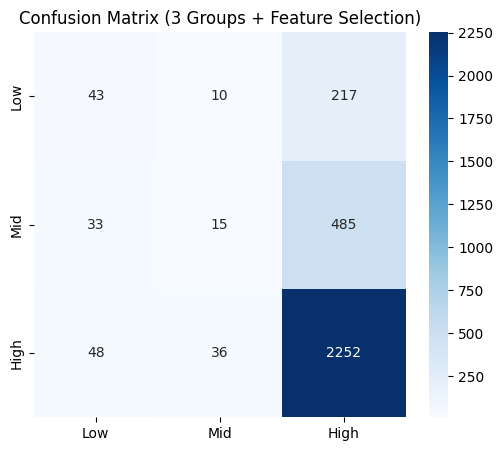

In [ ]:
df = pd.read_csv('cleaned_yrbs_data.csv')

# map รวมกลุ่มเกรด (3 กลุ่ม -> 0,1 = Low | 2 = Mid | 3, 4 = High)
grade_map = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}
y = df['grade'].astype(int).map(grade_map)

# กำหนด Features ทั้งหมด
categorical_cols = ['gender', 'education_level', 'considered_suicide', 'sleep_place']
numerical_cols = [c for c in df.columns if c not in categorical_cols + ['grade']]

# Feature Engineering
# Health & Lifestyle Group
health_cols = ['hours_of_sleep', 'exercise', 'mental_health', 'ADHD']
df['health_score'] = df[health_cols].sum(axis=1)
df['health_risk'] = ((df['hours_of_sleep'] < 7) | (df['mental_health'] > 2) | (df['ADHD'] > 0)).astype(int)
df['sleep_exercise_interaction'] = df['hours_of_sleep'] * df['exercise']
df['mental_adhd_interaction'] = df['mental_health'] * df['ADHD']

# Alcohol Use Group
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']
df['alcohol_exposure'] = df[alcohol_cols].sum(axis=1)
df['alcohol_progression'] = df['alcohol_frequency'] - df['first_alcohol']
df['high_alcohol_use'] = ((df['alcohol_frequency'] > 0) | (df['hardcore_alcohol_frequency'] > 0)).astype(int)

# Family Environment Group
family_cols = ['parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'parent_monitoring']
df['family_adversity_score'] = df[family_cols[:-1]].sum(axis=1)  # Exclude monitoring
df['family_protective_score'] = df['parent_monitoring'] + df['have_friend']
df['family_risk_ratio'] = df['family_adversity_score'] / (df['family_protective_score'] + 1)

# School Environment Group
school_cols = ['school_safety_concern', 'threatened_at_school', 'school_fight_count', 'school_racism', 'school_bullying', 'unfair_discipline_school']
df['school_stress_score'] = df[school_cols].sum(axis=1)
df['bullying_exposure'] = ((df['school_bullying'] > 0) | (df['cyber_bullying'] > 0)).astype(int)
df['school_violence_index'] = df['school_safety_concern'] + df['threatened_at_school'] + df['school_fight_count']

# Social & Peer Group
social_cols = ['social_media', 'have_friend']
df['social_engagement'] = df['social_media'] + df['have_friend']
df['social_risk'] = (df['social_media'] > 5).astype(int)
df['peer_support'] = df['have_friend']

# Violence & Safety Group
violence_cols = ['fight_count', 'neighborhood_violence', 'sexual_violence', 'ride_drinking_driver']
df['violence_exposure_score'] = df[violence_cols].sum(axis=1)
df['personal_violence'] = df['fight_count'] + df['sexual_violence']
df['environmental_violence'] = df['neighborhood_violence'] + df['ride_drinking_driver']

# Demographic & Developmental Group
demo_cols = ['age']
df['age_squared'] = df['age'] ** 2
df['adolescent_risk'] = ((df['age'] >= 14) & (df['age'] <= 17)).astype(int)

# Cross-domain Interactions
df['health_substance_risk'] = df['health_risk'] * df['high_alcohol_use']
df['family_school_stress'] = df['family_adversity_score'] * df['school_stress_score']
df['social_violence_link'] = df['social_risk'] * df['violence_exposure_score']

# Update numerical columns list with all new features
grouped_features = [
    'health_score', 'health_risk', 'sleep_exercise_interaction', 'mental_adhd_interaction',
    'alcohol_exposure', 'alcohol_progression', 'high_alcohol_use',
    'family_adversity_score', 'family_protective_score', 'family_risk_ratio',
    'school_stress_score', 'bullying_exposure', 'school_violence_index',
    'social_engagement', 'social_risk', 'peer_support',
    'violence_exposure_score', 'personal_violence', 'environmental_violence',
    'age_squared', 'adolescent_risk',
    'health_substance_risk', 'family_school_stress', 'social_violence_link'
]

numerical_cols.extend(grouped_features)

X = df[numerical_cols + categorical_cols]

# Fix Missing & Preprocessing
X = X.fillna(X.median(numeric_only=True))
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Split & SMOTE
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Feature Selector
# คัดเฉพาะตัวที่มีผลกับโมเดล -> ลด Noise
selector = SelectFromModel(XGBClassifier(n_estimators=100, max_depth=3), threshold='median')
X_train_selected = selector.fit_transform(X_train_res, y_train_res)
X_test_selected = selector.transform(X_test)

# train
model = XGBClassifier(
    n_estimators=533,
    learning_rate=0.0241,
    max_depth=3,
    min_child_weight=6,
    subsample=0.89,
    colsample_bytree=0.60,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

model.fit(X_train_selected, y_train_res)

# Evaluated model
y_pred = model.predict(X_test_selected)
print(f"Accuracy Score (3 Groups): {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Mid', 'High']))

# Confusion matrix checkk
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Mid', 'High'], yticklabels=['Low', 'Mid', 'High'])
plt.title('Confusion Matrix (3 Groups + Feature Selection)')
plt.show()